🌾 Seasonal Agriculture Performance Analysis

### Major Project – Data Analytics

**Objective:**  
To analyze agricultural performance across different seasons and identify meaningful
patterns, trends, relationships, differences and variations in agricultural performance.

### Key Areas of Analysis
- Data Exploration
- Data Cleaning and Preparation
- Descriptive and Statistical Analysis
- Univariate Analysis
- Bivariate Analysis
- Multivariate Analysis
- Correlation Analysis
- Seasonal Comparison
- Crop and Irrigation Analysis
- Environmental and Resource Analysis
- Economic Performance Analysis
- Student-Designed Analyses
- Insights and Recommendations
- Limitations
- Conclusion

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

# Statistical libraries
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Upload the CSV dataset

uploaded = files.upload()

print("File uploaded successfully!")

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv
File uploaded successfully!


In [5]:
# Find the uploaded CSV file
file_name = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("File name:", file_name)

Dataset loaded successfully!
File name: seasonal_agriculture_performance_dataset (1).csv


In [6]:
# Display basic information about the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of rows: 4000
Number of columns: 28

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3  

In [7]:
# Display first 5 rows

print("Top 5 Rows of the Dataset:")
display(df.head())

Top 5 Rows of the Dataset:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [8]:
# Display last 5 rows

print("Last 5 Rows of the Dataset:")
display(df.tail())

Last 5 Rows of the Dataset:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [9]:
# Examine dataset shape and structure

print("Dataset Shape:", df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names and Data Types:")
display(pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str),
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()
}).reset_index(drop=True))

Dataset Shape: (4000, 28)

Number of Rows: 4000
Number of Columns: 28

Column Names and Data Types:


,Column,Data Type,Missing Values,Unique Values
0,Farm_ID,object,0,4000
1,State,object,0,8
2,District,object,0,10
3,Crop,object,0,8
4,Season,object,0,3
5,Farm_Area_Hectares,float64,0,1370
6,Rainfall_mm,float64,48,3256
7,Avg_Temperature_C,float64,0,204
8,Humidity_pct,float64,0,573
9,Sunlight_Hours_Day,float64,0,71


In [10]:
# Examine data types

print("Numerical Columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical/Object Columns:")
print(df.select_dtypes(include='object').columns.tolist())

Numerical Columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical/Object Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [11]:
# Examine important categorical variables

categorical_columns = ['Season', 'State', 'District', 'Crop', 'Irrigation_Method']

for column in categorical_columns:
    print("\n" + "="*60)
    print(column)
    print("="*60)
    print(df[column].value_counts())


Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [12]:
# Check missing values

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Values': missing_values.values,
    'Missing Percentage': (missing_values.values / len(df) * 100).round(2)
})

missing_table = missing_table[missing_table['Missing Values'] > 0]

print("Missing Values Found:")
display(missing_table)

Missing Values Found:


,Column,Missing Values,Missing Percentage
6,Rainfall_mm,48,1.20
11,Soil_Moisture_pct,40,1.00
19,Yield_Tonnes_Ha,32,0.80


In [13]:
# Create a copy for cleaning

df_clean = df.copy()

# Numerical columns with missing values
numeric_missing_columns = [
    'Rainfall_mm',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha'
]

# Fill missing numerical values with median
for column in numeric_missing_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

print("Missing numerical values handled using median imputation.")

print("\nRemaining missing values:")
print(df_clean.isnull().sum().sum())

Missing numerical values handled using median imputation.

Remaining missing values:
0


In [14]:
# Check duplicate records

duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates()
    print("Duplicate records removed.")
else:
    print("No duplicate records found.")

Number of duplicate records: 0
No duplicate records found.


In [15]:
# Verify the cleaned dataset

print("Original Dataset Shape:", df.shape)
print("Cleaned Dataset Shape:", df_clean.shape)

print("\nRemaining Missing Values:")
print(df_clean.isnull().sum().sum())

print("\nRemaining Duplicate Rows:")
print(df_clean.duplicated().sum())

Original Dataset Shape: (4000, 28)
Cleaned Dataset Shape: (4000, 28)

Remaining Missing Values:
0

Remaining Duplicate Rows:
0


In [16]:
# Descriptive statistical analysis

print("Descriptive Statistics for Numerical Variables:")

display(df_clean.describe().T)

Descriptive Statistics for Numerical Variables:


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,4000.00,600.92,287.19,80.00,371.58,582.00,831.98,1395.20
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,4000.00,26.51,6.68,8.00,21.80,26.40,31.20,47.00
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [17]:
# Detailed statistical summary

numeric_columns = df_clean.select_dtypes(include=np.number).columns

statistics_summary = pd.DataFrame({
    'Mean': df_clean[numeric_columns].mean(),
    'Median': df_clean[numeric_columns].median(),
    'Standard Deviation': df_clean[numeric_columns].std(),
    'Minimum': df_clean[numeric_columns].min(),
    'Maximum': df_clean[numeric_columns].max()
})

display(statistics_summary.round(2))

,Mean,Median,Standard Deviation,Minimum,Maximum
Farm_Area_Hectares,7.89,7.90,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,1395.20
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


Number of records by season:


,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


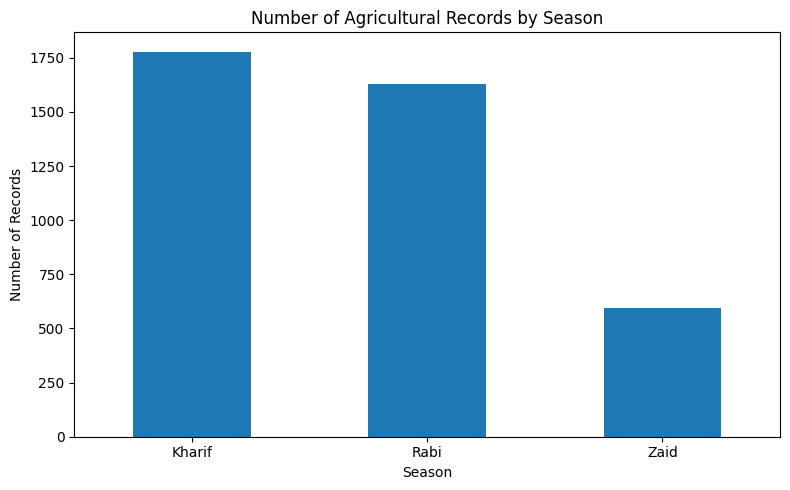

In [18]:
# Number of records in each season

season_counts = df_clean['Season'].value_counts()

print("Number of records by season:")
display(season_counts)

plt.figure(figsize=(8,5))
season_counts.plot(kind='bar')
plt.title('Number of Agricultural Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Number of records by crop:


,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


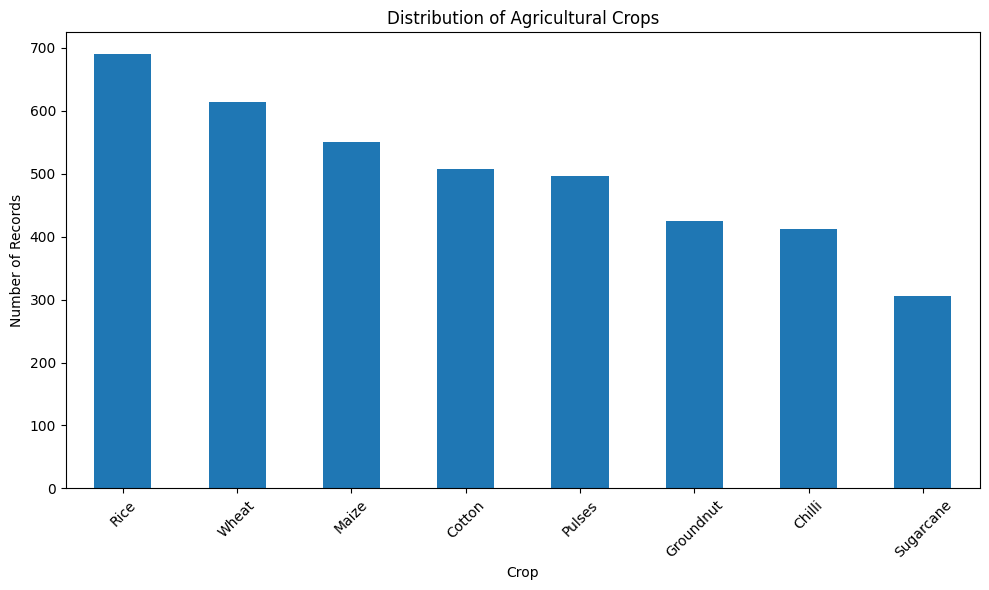

In [19]:
# Crop distribution

crop_counts = df_clean['Crop'].value_counts()

print("Number of records by crop:")
display(crop_counts)

plt.figure(figsize=(10,6))
crop_counts.plot(kind='bar')
plt.title('Distribution of Agricultural Crops')
plt.xlabel('Crop')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

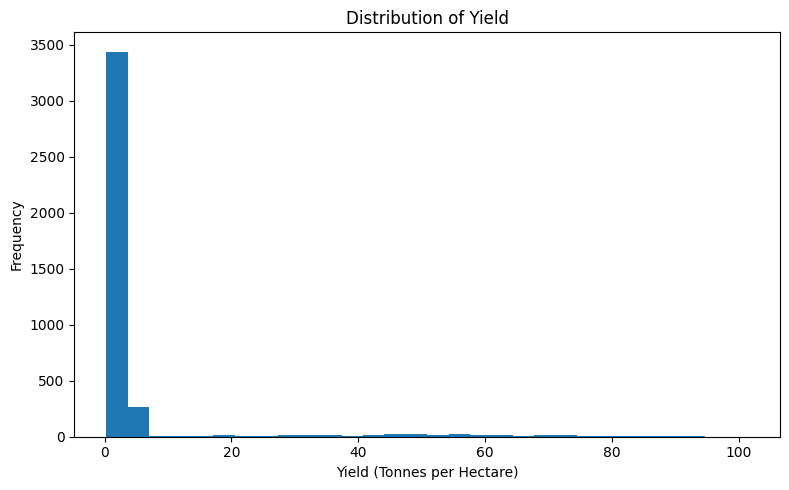

Yield Statistics:


,Yield_Tonnes_Ha
count,4000.00
mean,5.24
std,13.31
min,0.30
25%,1.05
50%,1.74
75%,2.83
max,101.44


In [20]:
# Univariate analysis of agricultural yield

plt.figure(figsize=(8,5))
plt.hist(df_clean['Yield_Tonnes_Ha'], bins=30)
plt.title('Distribution of Yield')
plt.xlabel('Yield (Tonnes per Hectare)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Yield Statistics:")
display(df_clean['Yield_Tonnes_Ha'].describe())

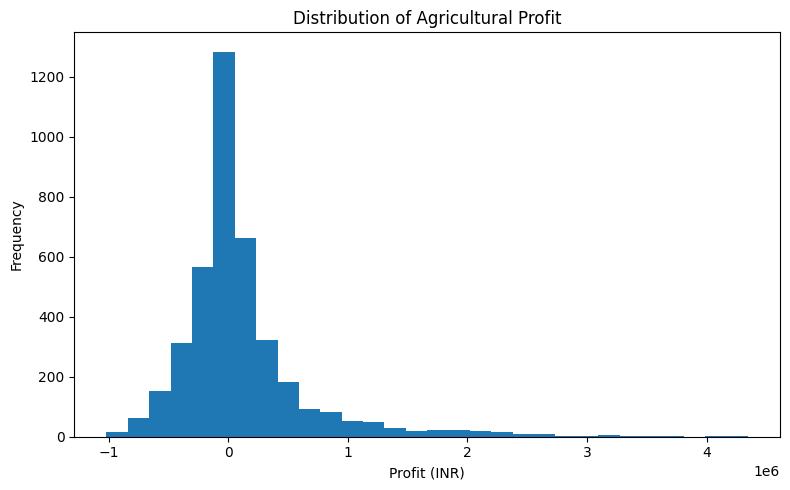

Profit Statistics:


,Profit_INR
count,4000.00
mean,111556.46
std,545081.89
min,-1019223.00
25%,-148731.75
50%,3673.00
75%,216187.75
max,4345421.00


In [21]:
# Univariate analysis of Profit

plt.figure(figsize=(8,5))
plt.hist(df_clean['Profit_INR'], bins=30)
plt.title('Distribution of Agricultural Profit')
plt.xlabel('Profit (INR)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Profit Statistics:")
display(df_clean['Profit_INR'].describe())

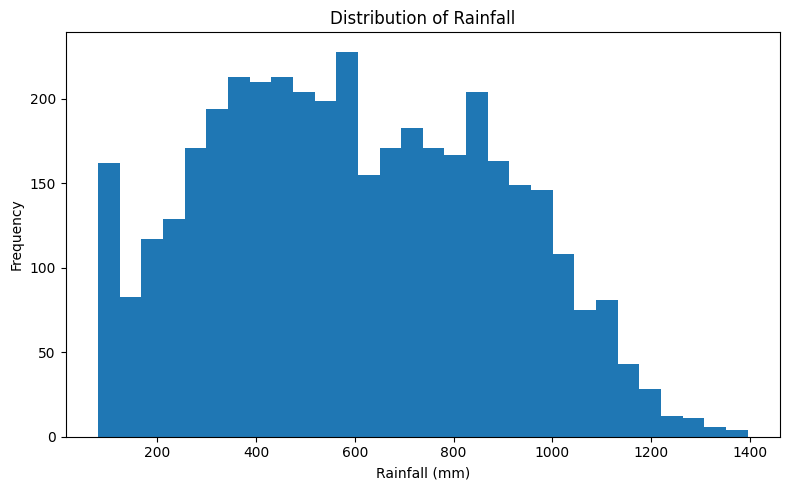

In [22]:
# Univariate analysis of rainfall

plt.figure(figsize=(8,5))
plt.hist(df_clean['Rainfall_mm'], bins=30)
plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [23]:
# Outlier investigation using IQR method

outlier_columns = [
    'Rainfall_mm',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

outlier_summary = []

for column in outlier_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    outlier_summary.append([
        column,
        Q1,
        Q3,
        lower_bound,
        upper_bound,
        len(outliers)
    ])

outlier_table = pd.DataFrame(
    outlier_summary,
    columns=[
        'Variable',
        'Q1',
        'Q3',
        'Lower Bound',
        'Upper Bound',
        'Number of Outliers'
    ]
)

display(outlier_table.round(2))

,Variable,Q1,Q3,Lower Bound,Upper Bound,Number of Outliers
0,Rainfall_mm,371.58,831.98,-319.02,1522.57,0
1,Yield_Tonnes_Ha,1.05,2.83,-1.62,5.50,302
2,Production_Tonnes,5.02,24.36,-23.98,53.36,333
3,Revenue_INR,207517.25,836874.75,-736519.00,1780911.00,240
4,Profit_INR,-148731.75,216187.75,-696111.00,763567.00,404
5,Water_Used_m3,2268.75,7829.75,-6072.75,16171.25,276
6,Water_Efficiency_t_per_1000m3,1.66,5.15,-3.57,10.38,322
7,Disease_Pest_Risk_pct,37.30,54.90,10.90,81.30,10


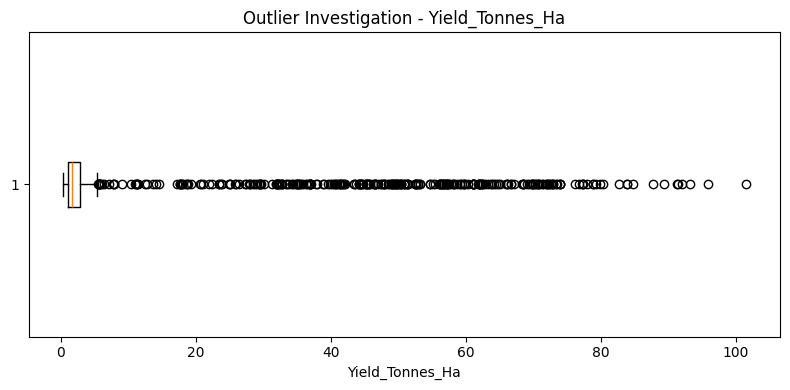

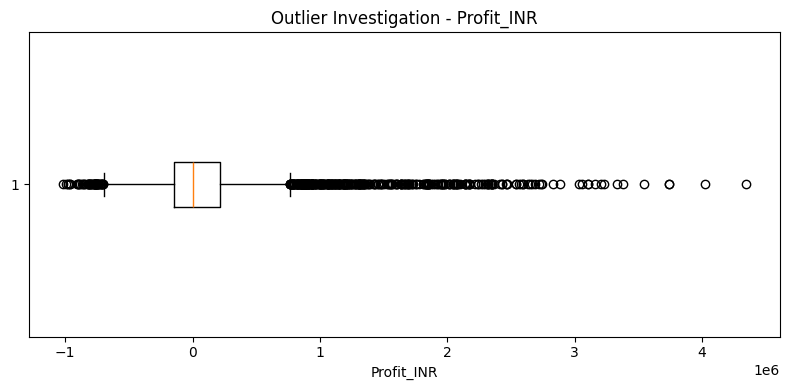

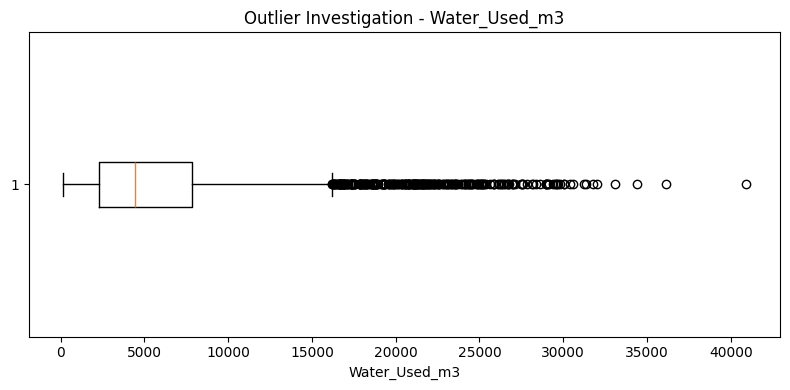

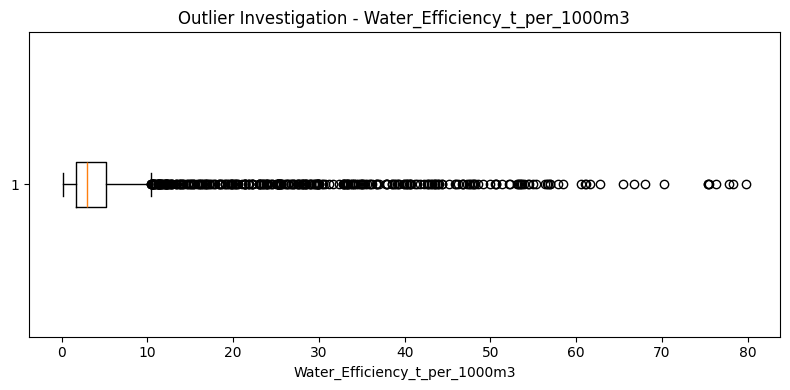

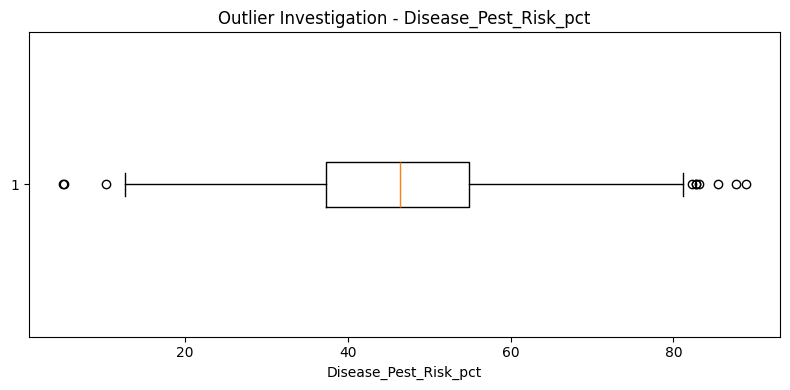

In [24]:
# Visual investigation of important outliers

variables = [
    'Yield_Tonnes_Ha',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

for column in variables:
    plt.figure(figsize=(8,4))
    plt.boxplot(df_clean[column].dropna(), vert=False)
    plt.title(f'Outlier Investigation - {column}')
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

### Outlier Investigation

The IQR method was used to identify potential outliers in important numerical
variables. Several variables contain observations outside the IQR boundaries,
particularly yield, profit, water usage and water efficiency.

These observations were investigated rather than automatically removed because
they may represent genuine differences between crops, farm sizes, production
levels and agricultural conditions. Removing them without domain justification
could remove meaningful agricultural information.

In [25]:
# Seasonal performance analysis

season_summary = df_clean.groupby('Season').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Median_Yield=('Yield_Tonnes_Ha', 'median'),
    Average_Production=('Production_Tonnes', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Cost=('Total_Cost_INR', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Water_Used=('Water_Used_m3', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Average_Disease_Risk=('Disease_Pest_Risk_pct', 'mean'),
    Average_Rainfall=('Rainfall_mm', 'mean')
).sort_values('Average_Profit', ascending=False)

display(season_summary.round(2))

,Average_Yield,Median_Yield,Average_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Water_Used,Average_Water_Efficiency,Average_Disease_Risk,Average_Rainfall
Season,,,,,,,,,,
Kharif,5.63,1.94,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47,849.20
Rabi,5.04,1.67,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48,437.62
Zaid,4.64,1.46,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22,304.65


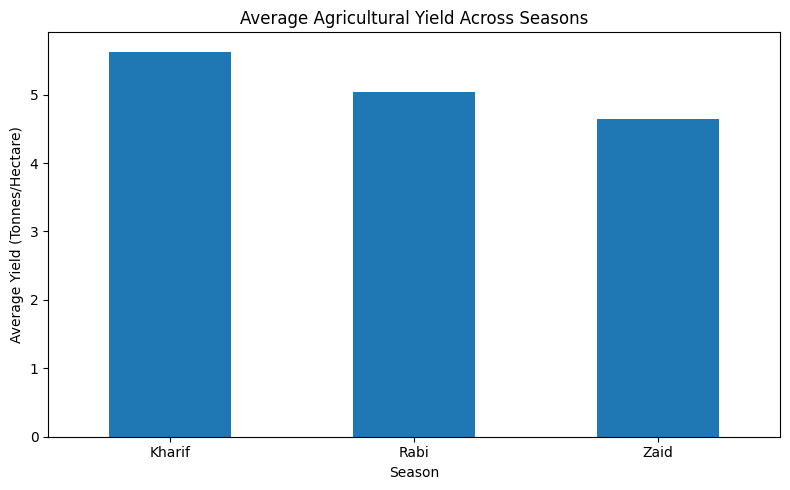

In [26]:
# Compare yield across seasons

plt.figure(figsize=(8,5))

season_yield = df_clean.groupby('Season')['Yield_Tonnes_Ha'].mean()

season_yield.plot(kind='bar')

plt.title('Average Agricultural Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Hectare)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

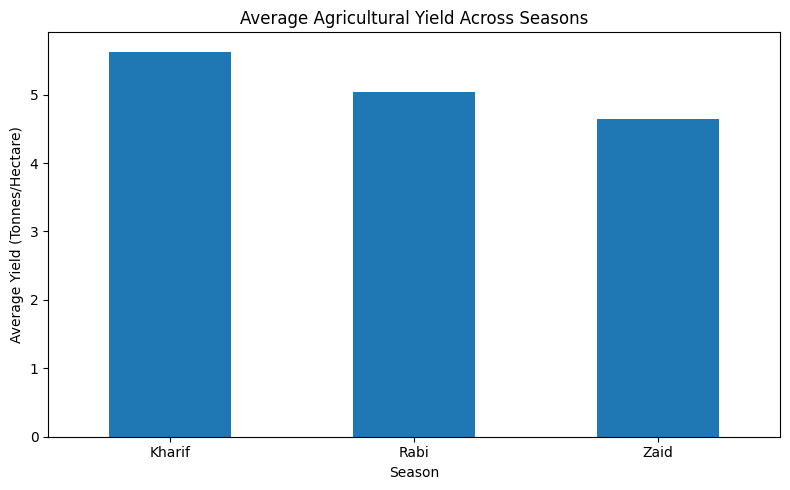

In [27]:
# Compare yield across seasons

plt.figure(figsize=(8,5))

season_yield = df_clean.groupby('Season')['Yield_Tonnes_Ha'].mean()

season_yield.plot(kind='bar')

plt.title('Average Agricultural Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Hectare)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.06,531804.41,178914.65
Rabi,601526.05,513836.58,87689.47
Zaid,519171.90,543976.73,-24804.82


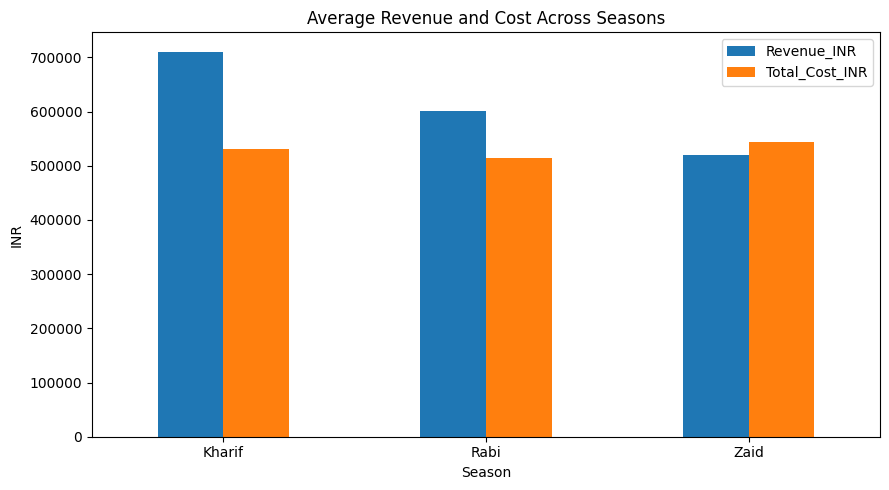

In [28]:
# Seasonal revenue and cost comparison

economic_summary = df_clean.groupby('Season')[
    ['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
].mean()

display(economic_summary.round(2))

economic_summary[['Revenue_INR', 'Total_Cost_INR']].plot(
    kind='bar',
    figsize=(9,5)
)

plt.title('Average Revenue and Cost Across Seasons')
plt.xlabel('Season')
plt.ylabel('INR')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,6102.20,5.89
Rabi,5846.99,5.19
Zaid,6419.89,4.41


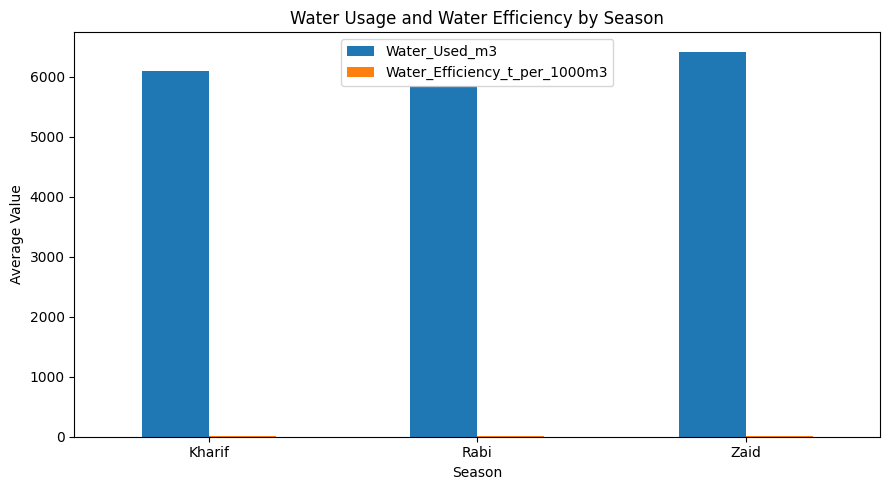

In [29]:
# Seasonal water usage

water_season = df_clean.groupby('Season')[
    ['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
].mean()

display(water_season.round(2))

water_season.plot(
    kind='bar',
    figsize=(9,5)
)

plt.title('Water Usage and Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Disease_Pest_Risk_pct
Season,
Kharif,54.47
Rabi,40.48
Zaid,38.22


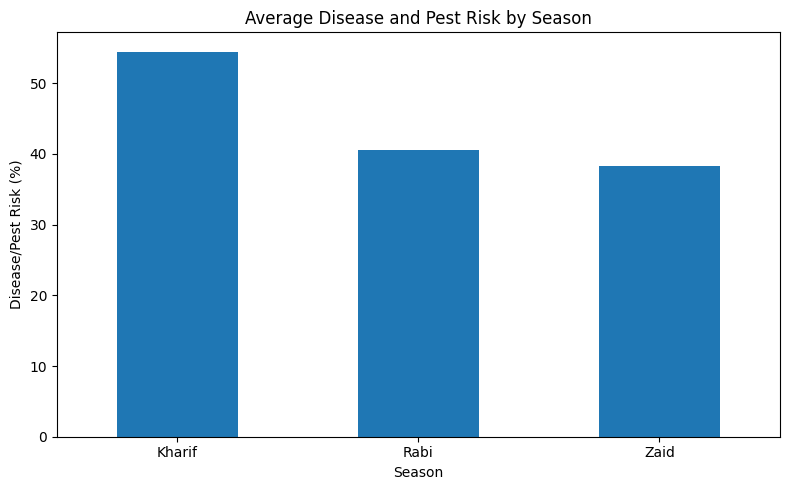

In [30]:
# Seasonal disease and pest risk

risk_season = df_clean.groupby('Season')['Disease_Pest_Risk_pct'].mean()

display(risk_season.round(2))

plt.figure(figsize=(8,5))
risk_season.plot(kind='bar')
plt.title('Average Disease and Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Disease/Pest Risk (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3932/2776538377.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


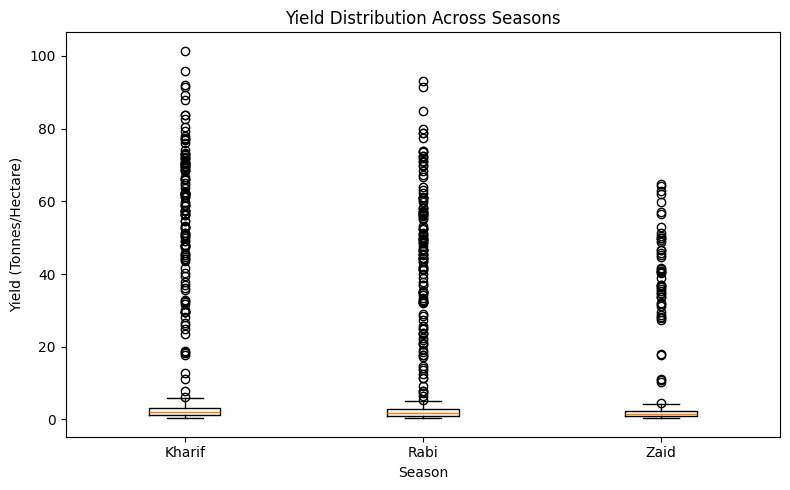

In [31]:
# Bivariate analysis: Season and Yield

season_yield_data = [
    df_clean[df_clean['Season'] == season]['Yield_Tonnes_Ha']
    for season in df_clean['Season'].unique()
]

plt.figure(figsize=(8,5))
plt.boxplot(
    season_yield_data,
    labels=df_clean['Season'].unique()
)

plt.title('Yield Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.tight_layout()
plt.show()

In [32]:
# Average performance by crop

crop_summary = df_clean.groupby('Crop').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Water_Use=('Water_Used_m3', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
).sort_values('Average_Profit', ascending=False)

display(crop_summary.round(2))

,Average_Yield,Average_Profit,Average_Revenue,Average_Water_Use,Average_Water_Efficiency
Crop,,,,,
Sugarcane,46.64,817187.99,1371980.11,13897.70,30.48
Chilli,1.54,750878.34,1276777.23,4577.47,2.95
Cotton,1.23,124546.92,639423.08,5410.86,1.94
Groundnut,1.32,44858.12,542935.50,3459.54,3.15
Pulses,0.92,-4238.05,528465.87,2833.67,2.90
Maize,2.71,-83978.33,457067.99,4377.78,5.60
Rice,2.43,-102213.50,423615.26,10920.22,1.95
Wheat,2.11,-123398.34,400104.89,4054.40,4.63


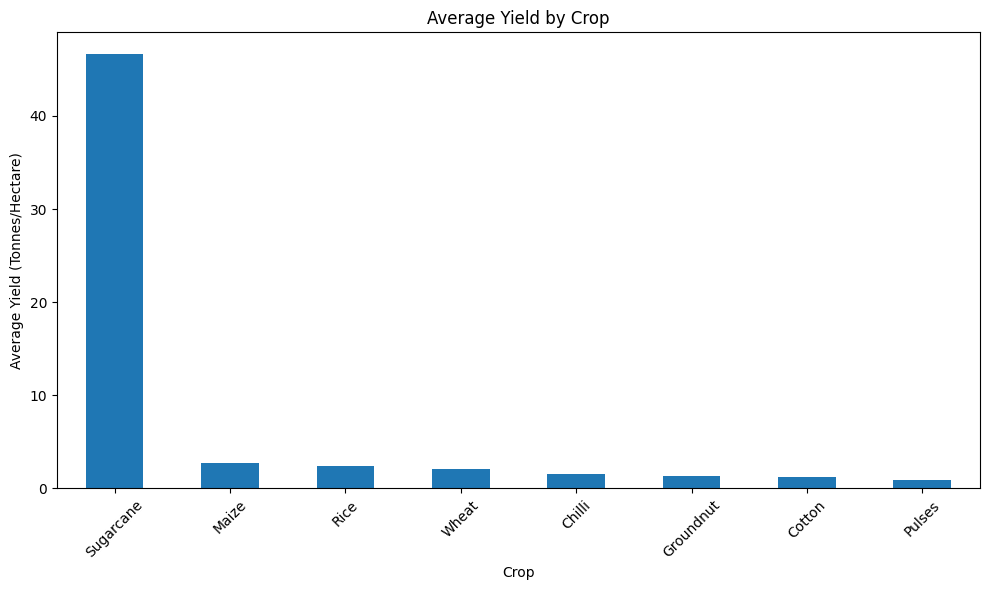

In [33]:
# Compare average yield by crop

crop_yield = df_clean.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
crop_yield.plot(kind='bar')

plt.title('Average Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Hectare)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

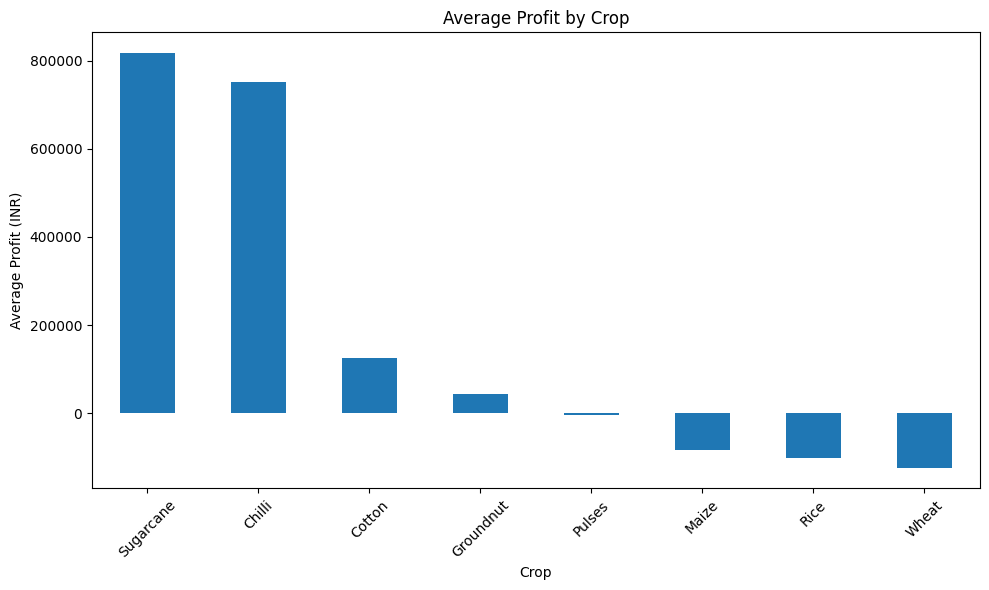

In [34]:
# Compare average profit by crop

crop_profit = df_clean.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
crop_profit.plot(kind='bar')

plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
# Student-Designed Analysis 1
# Which crop-season combination gives the best agricultural performance?

crop_season = df_clean.groupby(['Season', 'Crop']).agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Average_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
).reset_index()

print("Crop-Season Performance:")
display(crop_season.sort_values('Average_Profit', ascending=False).round(2))

print("\nTop 5 Crop-Season combinations by average profit:")
display(
    crop_season
    .sort_values('Average_Profit', ascending=False)
    .head(5)
    .round(2)
)

Crop-Season Performance:


,Season,Crop,Average_Yield,Average_Profit,Average_Revenue,Average_Water_Efficiency,Average_Disease_Risk
6,Kharif,Sugarcane,53.46,1000790.81,1561828.16,36.00,54.02
0,Kharif,Chilli,1.73,954380.42,1494091.73,3.26,52.81
14,Rabi,Sugarcane,43.29,731612.86,1269754.74,27.92,39.85
8,Rabi,Chilli,1.47,638572.50,1140992.37,2.89,40.59
22,Zaid,Sugarcane,38.42,583635.80,1165236.35,23.39,38.35
16,Zaid,Chilli,1.20,448659.09,994429.55,2.20,40.50
1,Kharif,Cotton,1.37,216999.55,713739.94,2.13,54.24
2,Kharif,Groundnut,1.48,108265.44,594414.86,3.58,54.28
9,Rabi,Cotton,1.20,107343.59,637722.18,1.94,41.54
4,Kharif,Pulses,1.04,43338.90,590276.29,3.35,54.96



Top 5 Crop-Season combinations by average profit:


,Season,Crop,Average_Yield,Average_Profit,Average_Revenue,Average_Water_Efficiency,Average_Disease_Risk
6,Kharif,Sugarcane,53.46,1000790.81,1561828.16,36.00,54.02
0,Kharif,Chilli,1.73,954380.42,1494091.73,3.26,52.81
14,Rabi,Sugarcane,43.29,731612.86,1269754.74,27.92,39.85
8,Rabi,Chilli,1.47,638572.50,1140992.37,2.89,40.59
22,Zaid,Sugarcane,38.42,583635.80,1165236.35,23.39,38.35


### Student-Designed Analysis 1: Crop-Season Performance

**Question:** Which crop and season combination provides the strongest overall
economic performance?

The analysis compares average yield, profit, revenue, water efficiency and
disease/pest risk for each crop-season combination. This allows agricultural
performance to be examined at a more detailed level instead of comparing
seasons only.

In [36]:
# Student-Designed Analysis 2
# How does irrigation method affect agricultural performance?

irrigation_summary = df_clean.groupby('Irrigation_Method').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Water_Used=('Water_Used_m3', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
).sort_values('Average_Profit', ascending=False)

print("Performance by Irrigation Method:")
display(irrigation_summary.round(2))

Performance by Irrigation Method:


,Average_Yield,Average_Profit,Average_Water_Used,Average_Water_Efficiency
Irrigation_Method,,,,
Drip,6.58,219626.00,5918.75,6.27
Sprinkler,5.16,91121.08,6208.26,4.67
Rainfed,4.60,79050.37,3549.55,7.56
Flood,4.86,73354.02,8026.47,3.44


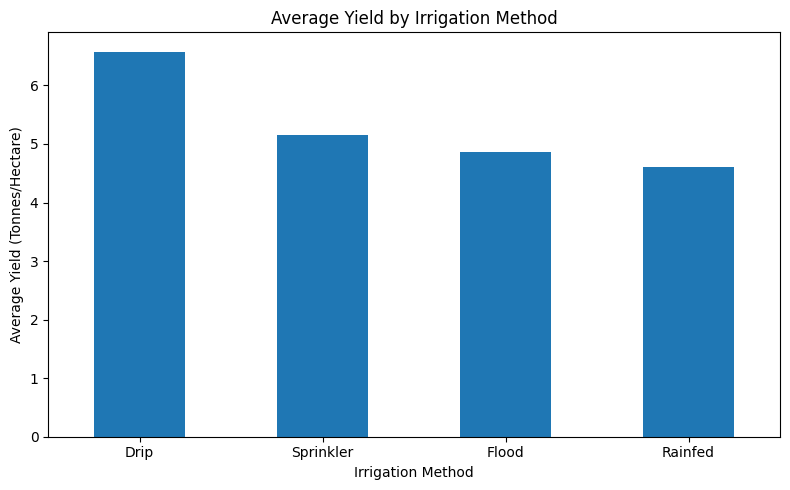

In [37]:
# Irrigation method vs yield

irrigation_yield = df_clean.groupby(
    'Irrigation_Method'
)['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
irrigation_yield.plot(kind='bar')

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Hectare)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

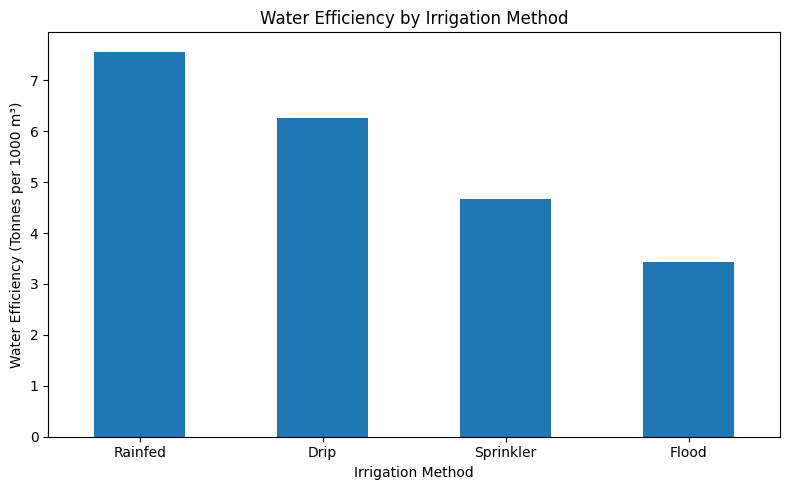

In [38]:
# Irrigation method vs water efficiency

irrigation_efficiency = df_clean.groupby(
    'Irrigation_Method'
)['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
irrigation_efficiency.plot(kind='bar')

plt.title('Water Efficiency by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Student-Designed Analysis 2: Irrigation Performance

**Question:** How does irrigation method influence yield, profit and water efficiency?

The analysis compares irrigation methods using agricultural yield, profit,
water consumption and water efficiency. This helps identify irrigation
practices that may provide better agricultural and economic outcomes.

In [39]:
# Student-Designed Analysis 3
# Relationship between environmental conditions and agricultural outcomes

environmental_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct'
]

environmental_yield_corr = df_clean[
    environmental_columns + ['Yield_Tonnes_Ha']
].corr()['Yield_Tonnes_Ha'].sort_values(ascending=False)

print("Correlation of Environmental Variables with Yield:")
display(environmental_yield_corr.round(3))

Correlation of Environmental Variables with Yield:


,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.00
Rainfall_mm,0.03
Humidity_pct,0.01
Soil_Moisture_pct,0.01
Avg_Temperature_C,0.01
Sunlight_Hours_Day,-0.01
Soil_pH,-0.02


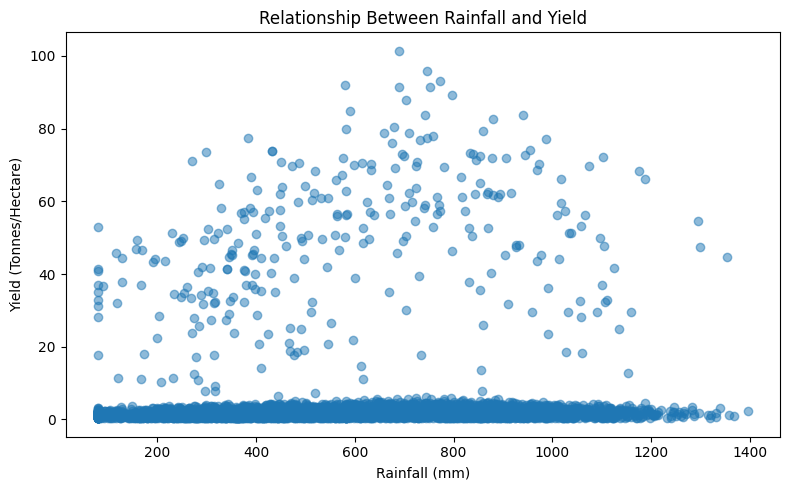

In [40]:
# Rainfall and yield relationship

plt.figure(figsize=(8,5))

plt.scatter(
    df_clean['Rainfall_mm'],
    df_clean['Yield_Tonnes_Ha'],
    alpha=0.5
)

plt.title('Relationship Between Rainfall and Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.tight_layout()
plt.show()

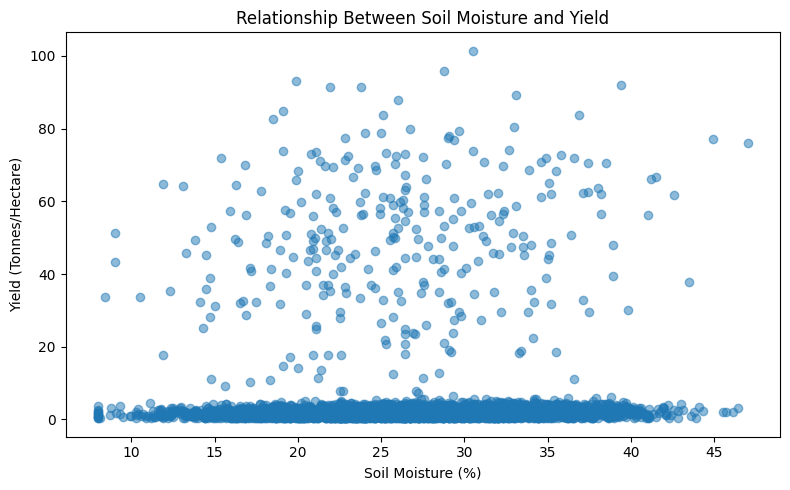

In [41]:
# Soil moisture and yield relationship

plt.figure(figsize=(8,5))

plt.scatter(
    df_clean['Soil_Moisture_pct'],
    df_clean['Yield_Tonnes_Ha'],
    alpha=0.5
)

plt.title('Relationship Between Soil Moisture and Yield')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.tight_layout()
plt.show()

### Student-Designed Analysis 3: Environmental Conditions

**Question:** What relationships exist between environmental conditions and
agricultural yield?

Rainfall, temperature, humidity, sunlight, soil pH and soil moisture were
compared with yield. Correlation and scatter plots were used to investigate
whether environmental conditions show noticeable relationships with
agricultural performance.

In [42]:
# Correlation analysis

numeric_df = df_clean.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

display(correlation_matrix.round(2))

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.00,0.01,0.04,0.00,0.00,0.01,0.00,0.01,-0.01,0.00,0.01,-0.01,0.02,0.03,0.20,-0.02,0.96,0.54,0.12,0.58,0.03,0.03
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.51,0.01,0.02,0.03,0.02,0.00,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.62
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,0.02,0.01,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,0.02,-0.00,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.02,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,-0.01,-0.01,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.00,0.51,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,0.01,-0.02,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,-0.03,0.01,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,-0.01,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,0.02,-0.00,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01


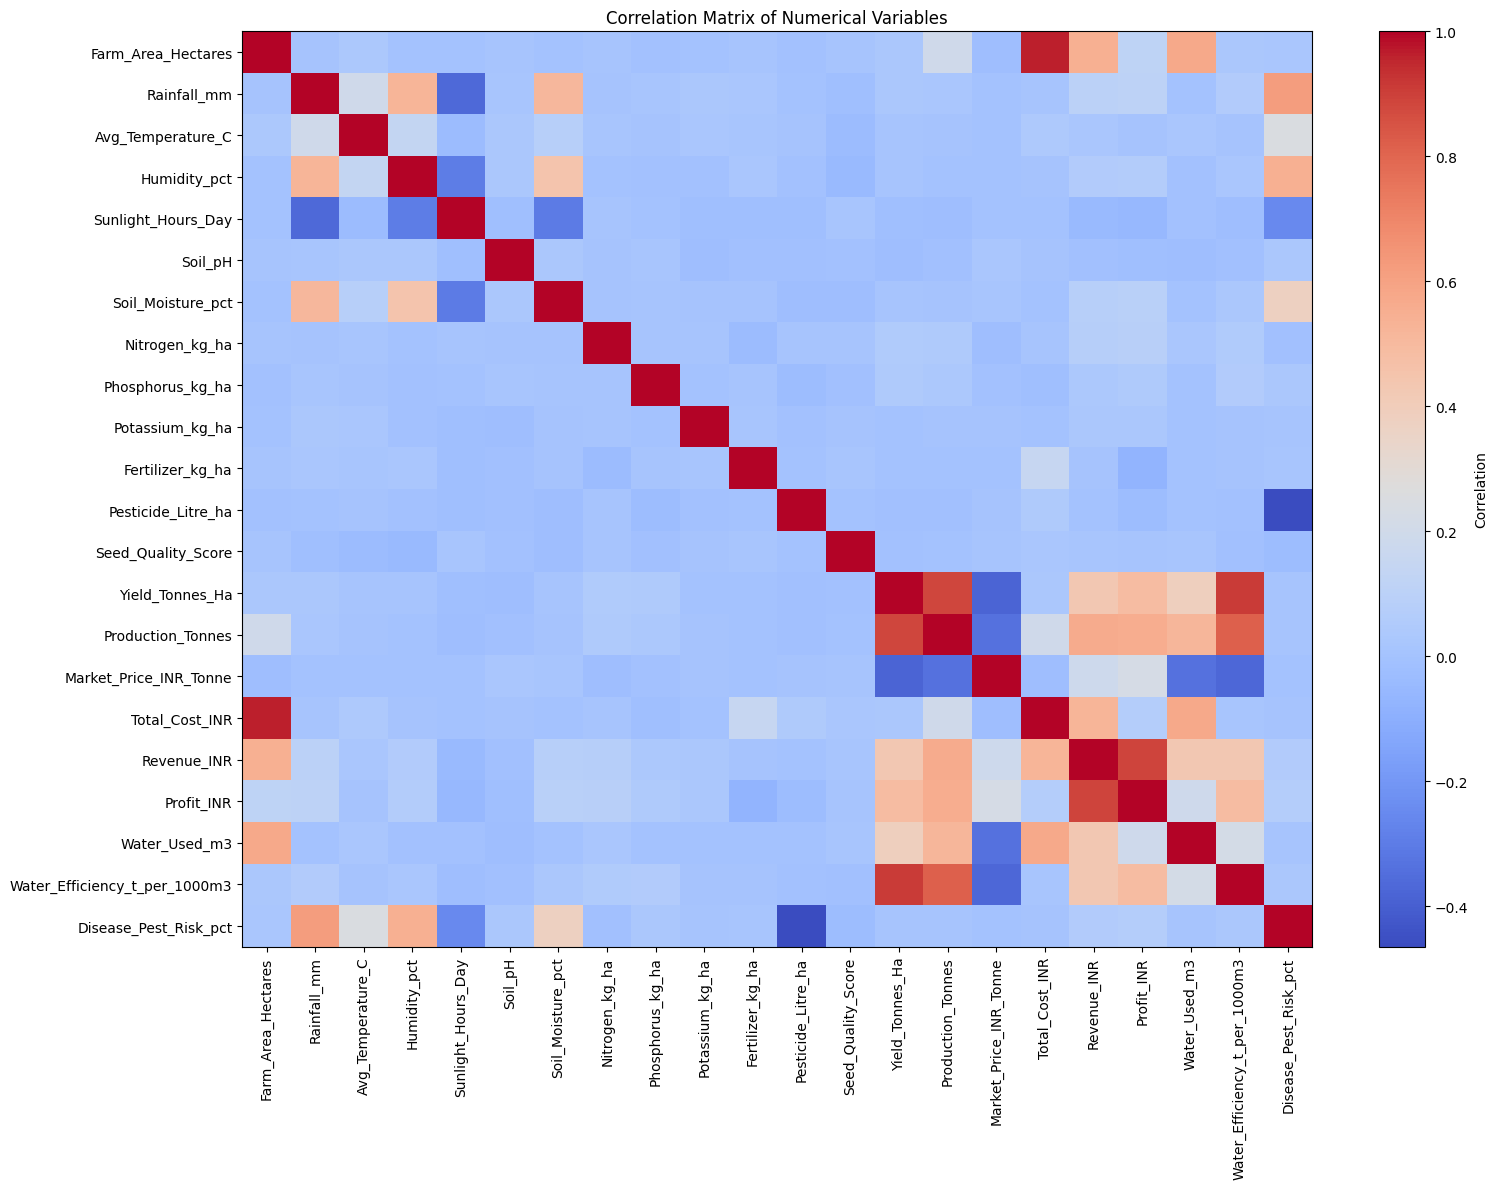

In [43]:
# Correlation heatmap using matplotlib

corr = numeric_df.corr()

plt.figure(figsize=(16,12))

plt.imshow(corr, cmap='coolwarm', aspect='auto')

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title('Correlation Matrix of Numerical Variables')

plt.tight_layout()
plt.show()

In [44]:
# Identify strongest correlations

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

corr_pairs['Absolute Correlation'] = corr_pairs['Correlation'].abs()

strongest_correlations = corr_pairs.sort_values(
    'Absolute Correlation',
    ascending=False
).head(15)

display(strongest_correlations.round(3))

,Variable 1,Variable 2,Correlation,Absolute Correlation
15,Farm_Area_Hectares,Total_Cost_INR,0.96,0.96
201,Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3,0.91,0.91
221,Revenue_INR,Profit_INR,0.89,0.89
195,Yield_Tonnes_Ha,Production_Tonnes,0.88,0.88
208,Production_Tonnes,Water_Efficiency_t_per_1000m3,0.81,0.81
40,Rainfall_mm,Disease_Pest_Risk_pct,0.62,0.62
18,Farm_Area_Hectares,Water_Used_m3,0.58,0.58
218,Total_Cost_INR,Water_Used_m3,0.58,0.58
205,Production_Tonnes,Revenue_INR,0.56,0.56
206,Production_Tonnes,Profit_INR,0.55,0.55


In [45]:
# Multivariate analysis

multivariate_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Water_Used_m3',
    'Yield_Tonnes_Ha',
    'Profit_INR'
]

multivariate_data = df_clean[multivariate_columns]

display(multivariate_data.describe().round(2))

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Water_Used_m3,Yield_Tonnes_Ha,Profit_INR
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,600.92,26.82,63.21,26.51,186.04,6045.57,5.24,111556.46
std,287.19,3.82,11.96,6.68,60.26,5572.94,13.31,545081.89
min,80.00,16.20,25.00,8.00,40.00,128.00,0.30,-1019223.00
25%,371.58,23.90,54.78,21.80,143.98,2268.75,1.05,-148731.75
50%,582.00,26.90,63.00,26.40,186.25,4435.00,1.74,3673.00
75%,831.98,29.60,71.90,31.20,227.20,7829.75,2.83,216187.75
max,1395.20,39.70,95.00,47.00,400.00,40902.00,101.44,4345421.00


In [46]:
# Multivariate analysis:
# Season and Crop together with agricultural yield

season_crop_yield = pd.pivot_table(
    df_clean,
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

print("Average Yield by Crop and Season:")
display(season_crop_yield.round(2))

Average Yield by Crop and Season:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


In [47]:
# Multivariate analysis:
# Season and Crop together with Profit

season_crop_profit = pd.pivot_table(
    df_clean,
    values='Profit_INR',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

print("Average Profit by Crop and Season:")
display(season_crop_profit.round(2))

Average Profit by Crop and Season:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.42,638572.50,448659.09
Cotton,216999.55,107343.59,-53925.34
Groundnut,108265.44,10416.54,-68872.50
Maize,-39332.67,-89133.40,-194049.17
Pulses,43338.90,-14309.14,-139227.81
Rice,-64903.40,-98427.87,-227239.34
Sugarcane,1000790.81,731612.86,583635.80
Wheat,-105871.87,-119954.57,-193208.95


In [48]:
# One-way ANOVA:
# Is there a statistically significant difference in yield among seasons?

kharif_yield = df_clean[
    df_clean['Season'] == 'Kharif'
]['Yield_Tonnes_Ha']

rabi_yield = df_clean[
    df_clean['Season'] == 'Rabi'
]['Yield_Tonnes_Ha']

zaid_yield = df_clean[
    df_clean['Season'] == 'Zaid'
]['Yield_Tonnes_Ha']

anova_result = stats.f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("ANOVA Test for Yield Across Seasons")
print("F-statistic:", round(anova_result.statistic, 4))
print("p-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("\nResult: There is a statistically significant difference in average yield across seasons.")
else:
    print("\nResult: No statistically significant difference was detected at the 5% significance level.")

ANOVA Test for Yield Across Seasons
F-statistic: 1.5439
p-value: 0.21367813841792296

Result: No statistically significant difference was detected at the 5% significance level.


In [49]:
# One-way ANOVA:
# Is there a statistically significant difference in profit among seasons?

kharif_profit = df_clean[
    df_clean['Season'] == 'Kharif'
]['Profit_INR']

rabi_profit = df_clean[
    df_clean['Season'] == 'Rabi'
]['Profit_INR']

zaid_profit = df_clean[
    df_clean['Season'] == 'Zaid'
]['Profit_INR']

profit_anova = stats.f_oneway(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

print("ANOVA Test for Profit Across Seasons")
print("F-statistic:", round(profit_anova.statistic, 4))
print("p-value:", profit_anova.pvalue)

if profit_anova.pvalue < 0.05:
    print("\nResult: There is a statistically significant difference in average profit across seasons.")
else:
    print("\nResult: No statistically significant difference was detected at the 5% significance level.")

ANOVA Test for Profit Across Seasons
F-statistic: 34.2918
p-value: 1.7124156677360182e-15

Result: There is a statistically significant difference in average profit across seasons.


In [50]:
# Compare agricultural resource usage across seasons

resource_summary = df_clean.groupby('Season').agg(
    Avg_Rainfall=('Rainfall_mm', 'mean'),
    Avg_Fertilizer=('Fertilizer_kg_ha', 'mean'),
    Avg_Pesticide=('Pesticide_Litre_ha', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Soil_Moisture=('Soil_Moisture_pct', 'mean')
)

display(resource_summary.round(2))

,Avg_Rainfall,Avg_Fertilizer,Avg_Pesticide,Avg_Water_Used,Avg_Soil_Moisture
Season,,,,,
Kharif,849.20,187.08,5.08,6102.20,31.15
Rabi,437.62,185.41,5.02,5846.99,24.07
Zaid,304.65,184.64,5.17,6419.89,19.28


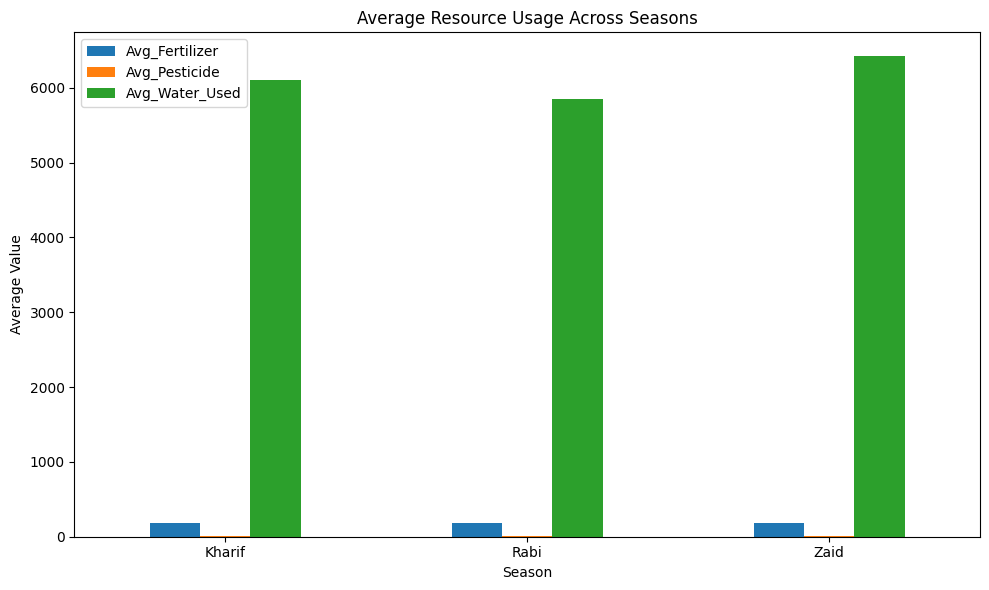

In [51]:
# Resource usage across seasons

resource_plot = resource_summary[
    ['Avg_Fertilizer', 'Avg_Pesticide', 'Avg_Water_Used']
]

resource_plot.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Average Resource Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [52]:
# Agricultural performance by state

state_summary = df_clean.groupby('State').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
).sort_values('Average_Profit', ascending=False)

display(state_summary.round(2))

,Average_Yield,Average_Profit,Average_Revenue,Average_Water_Efficiency
State,,,,
Punjab,6.12,136025.64,686225.70,5.62
Maharashtra,5.02,135428.86,650032.67,5.28
Karnataka,5.69,119422.34,653426.18,5.56
Tamil Nadu,4.88,117744.75,629093.42,5.31
Gujarat,5.66,117568.24,654692.86,5.58
Telangana,5.04,108829.62,628784.53,5.46
Madhya Pradesh,4.99,86840.76,597558.36,5.27
Andhra Pradesh,4.63,73453.53,606663.66,5.03


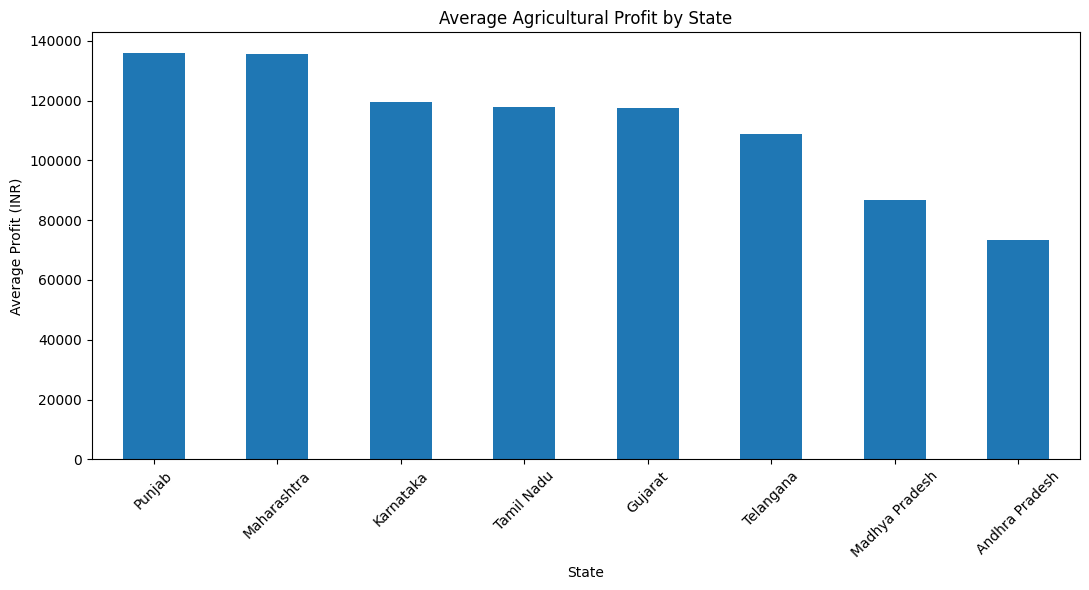

In [53]:
# State-wise average profit

plt.figure(figsize=(11,6))

state_profit = df_clean.groupby(
    'State'
)['Profit_INR'].mean().sort_values(ascending=False)

state_profit.plot(kind='bar')

plt.title('Average Agricultural Profit by State')
plt.xlabel('State')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


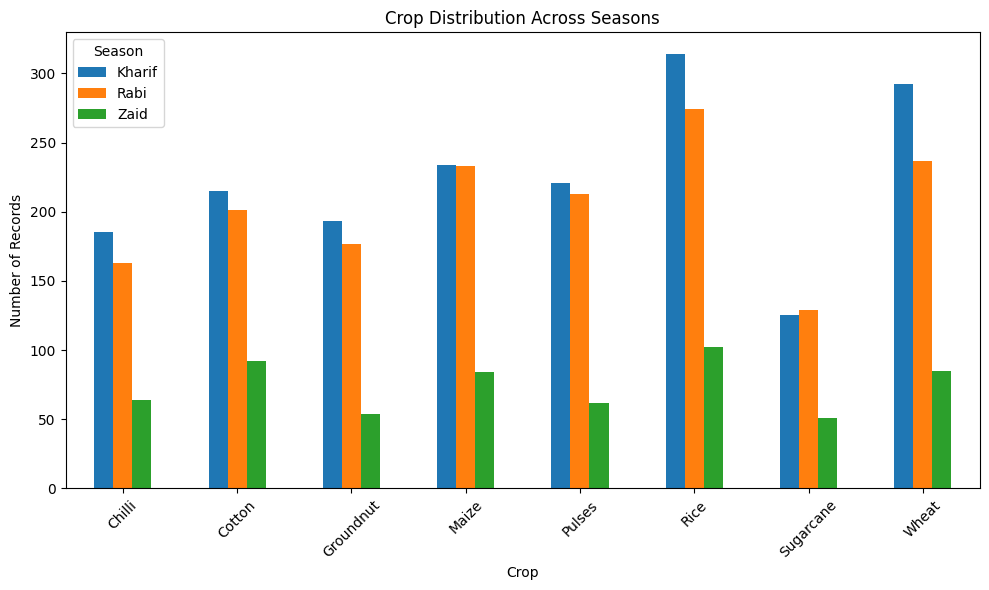

In [54]:
# Number of crops recorded in each season

season_crop_count = pd.crosstab(
    df_clean['Crop'],
    df_clean['Season']
)

display(season_crop_count)

season_crop_count.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Crop Distribution Across Seasons')
plt.xlabel('Crop')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
# Find the best crop-season combinations

top_combinations = crop_season.sort_values(
    'Average_Profit',
    ascending=False
).head(10)

print("Top 10 Crop-Season combinations by Average Profit:")
display(top_combinations.round(2))

Top 10 Crop-Season combinations by Average Profit:


,Season,Crop,Average_Yield,Average_Profit,Average_Revenue,Average_Water_Efficiency,Average_Disease_Risk
6,Kharif,Sugarcane,53.46,1000790.81,1561828.16,36.00,54.02
0,Kharif,Chilli,1.73,954380.42,1494091.73,3.26,52.81
14,Rabi,Sugarcane,43.29,731612.86,1269754.74,27.92,39.85
8,Rabi,Chilli,1.47,638572.50,1140992.37,2.89,40.59
22,Zaid,Sugarcane,38.42,583635.80,1165236.35,23.39,38.35
16,Zaid,Chilli,1.20,448659.09,994429.55,2.20,40.50
1,Kharif,Cotton,1.37,216999.55,713739.94,2.13,54.24
2,Kharif,Groundnut,1.48,108265.44,594414.86,3.58,54.28
9,Rabi,Cotton,1.20,107343.59,637722.18,1.94,41.54
4,Kharif,Pulses,1.04,43338.90,590276.29,3.35,54.96


In [56]:
# Water efficiency by season and crop

water_efficiency = df_clean.groupby(
    ['Season', 'Crop']
)['Water_Efficiency_t_per_1000m3'].mean().reset_index()

water_efficiency = water_efficiency.sort_values(
    'Water_Efficiency_t_per_1000m3',
    ascending=False
)

display(water_efficiency.head(15).round(2))

,Season,Crop,Water_Efficiency_t_per_1000m3
6,Kharif,Sugarcane,36.00
14,Rabi,Sugarcane,27.92
22,Zaid,Sugarcane,23.39
3,Kharif,Maize,6.05
11,Rabi,Maize,5.46
7,Kharif,Wheat,4.76
19,Zaid,Maize,4.75
15,Rabi,Wheat,4.69
23,Zaid,Wheat,4.02
2,Kharif,Groundnut,3.58


,Disease_Pest_Risk_pct
Crop,
Wheat,47.85
Pulses,46.57
Rice,46.50
Groundnut,46.29
Chilli,46.06
Cotton,45.97
Maize,45.54
Sugarcane,45.40


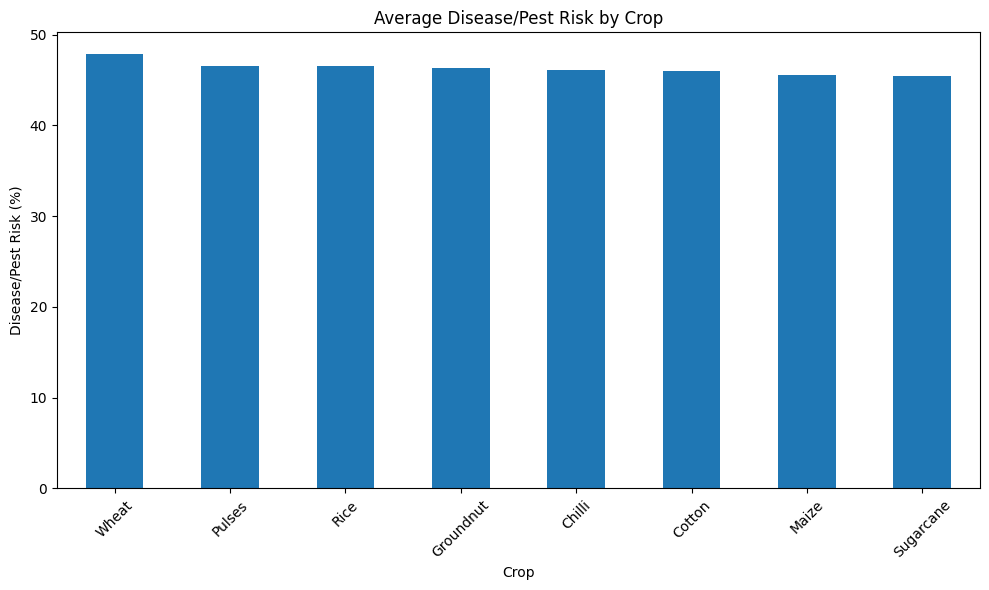

In [57]:
# Disease and pest risk by crop

crop_risk = df_clean.groupby(
    'Crop'
)['Disease_Pest_Risk_pct'].mean().sort_values(ascending=False)

display(crop_risk.round(2))

plt.figure(figsize=(10,6))

crop_risk.plot(kind='bar')

plt.title('Average Disease/Pest Risk by Crop')
plt.xlabel('Crop')
plt.ylabel('Disease/Pest Risk (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
# Automatically identify best and worst seasons

season_performance = df_clean.groupby('Season').agg(
    Yield=('Yield_Tonnes_Ha', 'mean'),
    Profit=('Profit_INR', 'mean'),
    Revenue=('Revenue_INR', 'mean'),
    Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
)

best_yield_season = season_performance['Yield'].idxmax()
best_profit_season = season_performance['Profit'].idxmax()
best_efficiency_season = season_performance['Water_Efficiency'].idxmax()
worst_profit_season = season_performance['Profit'].idxmin()

print("Best season by average yield:", best_yield_season)
print("Best season by average profit:", best_profit_season)
print("Best season by water efficiency:", best_efficiency_season)
print("Lowest-profit season:", worst_profit_season)

Best season by average yield: Kharif
Best season by average profit: Kharif
Best season by water efficiency: Kharif
Lowest-profit season: Zaid


In [59]:
# Generate evidence-based insights

season_stats = df_clean.groupby('Season').agg(
    Yield=('Yield_Tonnes_Ha', 'mean'),
    Profit=('Profit_INR', 'mean'),
    Revenue=('Revenue_INR', 'mean'),
    Cost=('Total_Cost_INR', 'mean'),
    Water=('Water_Used_m3', 'mean'),
    Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Risk=('Disease_Pest_Risk_pct', 'mean'),
    Rainfall=('Rainfall_mm', 'mean')
)

crop_stats = df_clean.groupby('Crop').agg(
    Yield=('Yield_Tonnes_Ha', 'mean'),
    Profit=('Profit_INR', 'mean'),
    Revenue=('Revenue_INR', 'mean'),
    Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Water=('Water_Used_m3', 'mean')
)

irrigation_stats = df_clean.groupby('Irrigation_Method').agg(
    Yield=('Yield_Tonnes_Ha', 'mean'),
    Profit=('Profit_INR', 'mean'),
    Water=('Water_Used_m3', 'mean'),
    Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
)

best_yield_season = season_stats['Yield'].idxmax()
best_profit_season = season_stats['Profit'].idxmax()
best_efficiency_season = season_stats['Efficiency'].idxmax()
highest_risk_season = season_stats['Risk'].idxmax()
highest_water_season = season_stats['Water'].idxmax()

best_yield_crop = crop_stats['Yield'].idxmax()
best_profit_crop = crop_stats['Profit'].idxmax()
best_efficiency_crop = crop_stats['Efficiency'].idxmax()

best_yield_irrigation = irrigation_stats['Yield'].idxmax()
best_profit_irrigation = irrigation_stats['Profit'].idxmax()
best_efficiency_irrigation = irrigation_stats['Efficiency'].idxmax()

print("========== 10 KEY INSIGHTS ==========\n")

print(f"1. {best_yield_season} recorded the highest average agricultural yield "
      f"at {season_stats.loc[best_yield_season, 'Yield']:.2f} tonnes/hectare.")

print(f"2. {best_profit_season} recorded the highest average profit "
      f"of ₹{season_stats.loc[best_profit_season, 'Profit']:,.2f}.")

print(f"3. {highest_risk_season} had the highest average disease/pest risk "
      f"at {season_stats.loc[highest_risk_season, 'Risk']:.2f}%.")

print(f"4. {highest_water_season} had the highest average water usage "
      f"at {season_stats.loc[highest_water_season, 'Water']:,.2f} m³.")

print(f"5. {best_efficiency_season} achieved the highest average water efficiency "
      f"at {season_stats.loc[best_efficiency_season, 'Efficiency']:.2f} tonnes per 1000 m³.")

print(f"6. {best_yield_crop} had the highest average yield among the crops "
      f"at {crop_stats.loc[best_yield_crop, 'Yield']:.2f} tonnes/hectare.")

print(f"7. {best_profit_crop} had the highest average profit among the crops "
      f"at ₹{crop_stats.loc[best_profit_crop, 'Profit']:,.2f}.")

print(f"8. {best_efficiency_crop} recorded the highest average water efficiency "
      f"among the crops at {crop_stats.loc[best_efficiency_crop, 'Efficiency']:.2f} tonnes per 1000 m³.")

print(f"9. {best_yield_irrigation} had the highest average yield among irrigation methods "
      f"at {irrigation_stats.loc[best_yield_irrigation, 'Yield']:.2f} tonnes/hectare.")

print(f"10. {best_profit_irrigation} generated the highest average profit among irrigation methods "
      f"at ₹{irrigation_stats.loc[best_profit_irrigation, 'Profit']:,.2f}.")

========== 10 KEY INSIGHTS ==========

1. Kharif recorded the highest average agricultural yield at 5.63 tonnes/hectare.
2. Kharif recorded the highest average profit of ₹178,914.65.
3. Kharif had the highest average disease/pest risk at 54.47%.
4. Zaid had the highest average water usage at 6,419.89 m³.
5. Kharif achieved the highest average water efficiency at 5.89 tonnes per 1000 m³.
6. Sugarcane had the highest average yield among the crops at 46.64 tonnes/hectare.
7. Sugarcane had the highest average profit among the crops at ₹817,187.99.
8. Sugarcane recorded the highest average water efficiency among the crops at 30.48 tonnes per 1000 m³.
9. Drip had the highest average yield among irrigation methods at 6.58 tonnes/hectare.
10. Drip generated the highest average profit among irrigation methods at ₹219,626.00.


In [60]:
# Create a concise findings table

findings = pd.DataFrame({
    'Metric': [
        'Highest Yield Season',
        'Highest Profit Season',
        'Highest Water Efficiency Season',
        'Highest Disease/Pest Risk Season',
        'Highest Water Usage Season',
        'Highest Yield Crop',
        'Highest Profit Crop',
        'Highest Yield Irrigation Method',
        'Highest Profit Irrigation Method',
        'Highest Water Efficiency Irrigation Method'
    ],
    'Result': [
        best_yield_season,
        best_profit_season,
        best_efficiency_season,
        highest_risk_season,
        highest_water_season,
        best_yield_crop,
        best_profit_crop,
        best_yield_irrigation,
        best_profit_irrigation,
        best_efficiency_irrigation
    ]
})

display(findings)

,Metric,Result
0,Highest Yield Season,Kharif
1,Highest Profit Season,Kharif
2,Highest Water Efficiency Season,Kharif
3,Highest Disease/Pest Risk Season,Kharif
4,Highest Water Usage Season,Zaid
5,Highest Yield Crop,Sugarcane
6,Highest Profit Crop,Sugarcane
7,Highest Yield Irrigation Method,Drip
8,Highest Profit Irrigation Method,Drip
9,Highest Water Efficiency Irrigation Method,Rainfed


# 🌱 Evidence-Based Recommendations

Based on the analysis of seasonal agricultural performance, the following
recommendations are proposed:

### 1. Season-specific planning
Agricultural planning should consider seasonal differences because yield,
profitability, water usage and disease/pest risk vary between Kharif, Rabi
and Zaid seasons.

### 2. Focus on profitable seasons
The season with the highest average profit should be prioritized where
environmental and resource conditions permit.

### 3. Improve water management
Water usage and water efficiency should be monitored carefully, particularly
during seasons with higher water consumption.

### 4. Consider efficient irrigation methods
The comparison of irrigation methods shows differences in yield, profit,
water consumption and water efficiency. Farmers should select irrigation
methods according to crop requirements and local water availability.

### 5. Crop selection should consider both profit and resources
High-profit crops should not be evaluated using profit alone. Water
requirements, yield, disease risk and production costs should also be
considered.

### 6. Strengthen disease and pest monitoring
Seasons or crops with higher disease/pest risk should receive increased
monitoring and preventive management.

### 7. Use environmental information in planning
Rainfall, soil moisture, temperature, humidity and other environmental
variables should be monitored when planning seasonal agricultural activities.

### 8. Investigate unusual observations
Extreme values in yield, production, revenue, profit and water efficiency
should be investigated individually before making operational decisions.

### 9. Improve resource allocation
Fertilizer, pesticide, irrigation water and other inputs should be allocated
according to crop and seasonal requirements rather than applying the same
strategy across all conditions.

### 10. Use data-driven decision making
Future agricultural planning should combine historical seasonal performance,
resource usage, environmental conditions and economic outcomes to improve
decision making.

# ⚠️ Limitations of the Analysis

1. The analysis is based only on the variables available in the provided
   dataset.

2. Missing numerical observations were handled using median imputation,
   which may not perfectly represent the original values.

3. Several numerical variables contain extreme observations. These were
   investigated as potential outliers instead of being automatically removed.

4. Correlation identifies association between variables but does not establish
   causal relationships.

5. The dataset does not contain an explicit date/year time-series variable,
   so the analysis compares records by agricultural season rather than
   studying long-term year-to-year trends.

6. Differences between crops may influence seasonal averages because the
   composition of crops is not necessarily identical across seasons.

7. Economic outcomes can depend on market conditions, costs and crop choice,
   so observed profit differences should not be interpreted as being caused
   by season alone.

8. The findings should therefore be interpreted as evidence from the available
   dataset rather than universal agricultural conclusions.

# 🎯 Conclusion

The Seasonal Agriculture Performance Analysis demonstrates that agricultural
performance varies across seasons, crops, irrigation methods and environmental
conditions.

The analysis examined the structure and quality of the dataset, handled missing
values and checked for duplicate records and potential outliers. Descriptive
statistics and visualizations were then used to understand the distribution
of agricultural variables.

Seasonal comparisons showed differences in yield, revenue, cost, profit,
water usage, water efficiency and disease/pest risk. Crop-level and
irrigation-level analyses provided additional information about agricultural
and economic performance.

Correlation and multivariate analysis were used to investigate relationships
among environmental conditions, resources and agricultural outcomes.
Three student-designed analyses further examined crop-season combinations,
irrigation methods and environmental conditions.

Overall, the findings demonstrate the importance of season-specific,
crop-specific and resource-aware agricultural planning. Data analytics can
support better decisions by identifying profitable opportunities, improving
resource allocation, monitoring agricultural risks and encouraging more
efficient use of water and other inputs.

The conclusions should be interpreted within the limitations of the available
dataset and should not be considered proof of causal relationships.

# ✅ Final Submission Checklist

- [1] Dataset loaded successfully
- [2] Top 5 rows analyzed
- [3] Dataset shape and structure examined
- [4] Data types examined
- [5] Missing values identified and handled
- [6] Duplicate records identified and handled
- [7] Descriptive/statistical analysis performed
- [8] Outliers investigated
- [9] Univariate analysis completed
- [10] Bivariate analysis completed
- [11] Multivariate analysis completed
- [12] Correlation analysis completed
- [13] Seasonal comparisons performed
- [14] At least 3 student-designed analyses completed
- [15] At least 8 meaningful insights documented
- [16] Evidence-based recommendations provided
- [17] Limitations discussed
- [18] Final conclusion provided